### Data Splitting
The data proportion would be 70% training, 15% validation, 15% testing

In [2]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split


#### Configuration
---

In [3]:

ORIGINAL_DATASET = r"C:\Users\USER\Documents\Thesis Dataset\Original Dataset"

# Defining path variables for splitting the data
BASE_OUTPUT = r"C:\Users\USER\Documents\Thesis Dataset\Processed Dataset"
TRAIN_DIR = os.path.join(BASE_OUTPUT, "train")
VAL_DIR   = os.path.join(BASE_OUTPUT, "val")
TEST_DIR  = os.path.join(BASE_OUTPUT, "test")

# Splitting percentage or proportion
train_ratio = 0.70
val_ratio   = 0.15
test_ratio  = 0.15

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png")

#### Clean and Create Directories 

Remove old processed data to avoid duplicates and create paths for training, validation and testing

In [4]:

# Deletes an already existed file
if os.path.exists(BASE_OUTPUT):
    shutil.rmtree(BASE_OUTPUT)

# Creates the directory for the path variables
for dir_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    os.makedirs(dir_path, exist_ok=True)


#### SPLIT & COPY FUNCTION

In [5]:

def split_and_copy(class_images, train_path, val_path, test_path):
    """Split the list of image paths into train/val/test and copy once."""
    if len(class_images) < 3:
        print(f"Folder is Empty or does not have an image: {os.path.basename(train_path)}")
        return

    random.shuffle(class_images)

    # Splitting Data: Train vs Temp (Val+Test)
    train_imgs, temp_imgs = train_test_split(
        class_images, test_size=(1 - train_ratio), random_state=42
    )
    # Splitting the Temp: Validation and Test
    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=(test_ratio / (test_ratio + val_ratio)),
        random_state=42,
    )

    # Copy each image
    for img in train_imgs:
        shutil.copy2(img, train_path)
    for img in val_imgs:
        shutil.copy2(img, val_path)
    for img in test_imgs:
        shutil.copy2(img, test_path)


#### Main loop
Loop for each plant to be splitted and copy to the processed folder

split and copy function is used

In [6]:
for disease_class in sorted(os.listdir(ORIGINAL_DATASET)):
    class_path = os.path.join(ORIGINAL_DATASET, disease_class)
    if not os.path.isdir(class_path):
        continue

    images = [
        os.path.join(class_path, f)
        for f in os.listdir(class_path)
        if f.lower().endswith(IMG_EXTENSIONS)
    ]

    train_out = os.path.join(TRAIN_DIR, disease_class)
    val_out = os.path.join(VAL_DIR, disease_class)
    test_out = os.path.join(TEST_DIR, disease_class)

    os.makedirs(train_out, exist_ok=True)
    os.makedirs(val_out, exist_ok=True)
    os.makedirs(test_out, exist_ok=True)

    split_and_copy(images, train_out, val_out, test_out)

    print(f"{disease_class}: {len(images)} images processed ✅")

print("🎉 Dataset successfully split into 70% Train, 15% Validation, 15% Test!")

Banana_Cordana: 442 images processed ✅
Banana_Healthy: 1108 images processed ✅
Banana_Panama Disease: 835 images processed ✅
Banana_Pestalotiopsis: 117 images processed ✅
Banana_Yellow and Black Sigatoka: 2597 images processed ✅
Coconut_Bud Root Dropping: 514 images processed ✅
Coconut_Bud Rot: 470 images processed ✅
Coconut_Gray Leaf Spot: 2135 images processed ✅
Coconut_Healthy: 123 images processed ✅
Coconut_Leaf Rot: 1673 images processed ✅
Coconut_WCLWD_DryingofLeaflets: 1078 images processed ✅
Coconut_WCLWD_Flaccidity: 1069 images processed ✅
Coconut_WCLWD_Yellowing: 1084 images processed ✅
Sugarcane_Healthy: 522 images processed ✅
Sugarcane_Mosaic: 462 images processed ✅
Sugarcane_RedRot: 518 images processed ✅
Sugarcane_Rust: 514 images processed ✅
Sugarcane_Yellow: 505 images processed ✅
🎉 Dataset successfully split into 70% Train, 15% Validation, 15% Test!


### Data Augmentation
We will manipulate the data using **horizontal flip**, **vertical flip**, **brighten**, **darken**, **rotate**, and **contrast**.

In [7]:
import os
import random
from pathlib import Path
from PIL import Image, ImageEnhance, ImageOps
import numpy as np


#### ⚙️ Configurationn

In [8]:

# Original training set folder directory
TRAIN_DIR = r"C:\Users\USER\Documents\Thesis Dataset\Processed Dataset\train"

# New folder for augmented images
AUGMENT_DIR = r"C:\Users\USER\Documents\Thesis Dataset\Processed Dataset\train_augmented"

IMG_EXTENSIONS = (".jpg", ".jpeg", ".png")

# Augmentation parameter ranges
ROTATE_ANGLE = 25
BRIGHTNESS_RANGE = (0.7, 1.4)   # random brightness factor
CONTRAST_RANGE = (0.7, 1.4)     # random contrast factor
GAMMA_RANGE = (0.8, 1.4)        # gamma correction range
NOISE_STD = 10                  # Gaussian noise standard deviation

### 🧩 Data Augmentation Functions
Below are the different augmentation techniques used to diversify the training dataset:

| Function | Description |
|----------|-------------|
| `horizontal_flip` ↔️ | Flips the image **horizontally** (left ↔ right). |
| `vertical_flip` ↕️ | Flips the image **vertically** (top ↕ bottom). |
| `random_brightness` ☀️ | Randomly **brightens or darkens** the image within a controlled range. |
| `random_contrast` 🎨 | Randomly adjusts the **contrast** to simulate varying image clarity. |
| `gamma_correction` 🔆 | Applies **gamma adjustment** to handle different lighting conditions. |
| `add_noise` 🔊 | Adds **Gaussian noise** to simulate camera sensor variation. |
| `rotate` 🔄 | Rotates the image by **±25 degrees** and keeps the image size consistent. |

> 💡 **Tip:**  
> Applying these augmentations helps the model generalize better and handle variations in lighting, orientation, noise, and texture.


In [9]:
def horizontal_flip(img):
    return img.transpose(Image.FLIP_LEFT_RIGHT)

def vertical_flip(img):
    return img.transpose(Image.FLIP_TOP_BOTTOM)

def random_brightness(img):
    factor = random.uniform(*BRIGHTNESS_RANGE)
    return ImageEnhance.Brightness(img).enhance(factor)

def random_contrast(img):
    factor = random.uniform(*CONTRAST_RANGE)
    return ImageEnhance.Contrast(img).enhance(factor)

def rotate(img):
    angle = random.uniform(-ROTATE_ANGLE, ROTATE_ANGLE)
    return img.rotate(angle, expand=True).resize(img.size)

def gamma_correction(img):
    gamma = random.uniform(*GAMMA_RANGE)
    inv_gamma = 1.0 / gamma
    lut = [pow(i / 255, inv_gamma) * 255 for i in range(256)]
    lut = lut * 3
    return img.point(lut)

def add_noise(img):
    arr = np.array(img)
    noise = np.random.normal(0, NOISE_STD, arr.shape).astype(np.int16)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

# Dictionary of augmentations
AUGMENTATIONS = {
    "flipH": horizontal_flip,
    "flipV": vertical_flip,
    "bright": random_brightness,
    "contrast": random_contrast,
    "gamma": gamma_correction,
    "noise": add_noise,
    "rotate": rotate,
}

#### Folders for the augmented data

In [10]:
for root, dirs, _ in os.walk(TRAIN_DIR):
    rel_path = os.path.relpath(root, TRAIN_DIR)
    os.makedirs(os.path.join(AUGMENT_DIR, rel_path), exist_ok=True)

count_original = 0
count_augmented = 0

#### The augmentation process loop

In [11]:
for root, _, files in os.walk(TRAIN_DIR):
    for file in files:
        if file.lower().endswith(IMG_EXTENSIONS):

            src = os.path.join(root, file)
            img = Image.open(src).convert("RGB")
            count_original += 1

            rel_path = os.path.relpath(root, TRAIN_DIR)
            save_base = os.path.join(AUGMENT_DIR, rel_path)
            base_name, ext = os.path.splitext(file)

            for aug_name, aug_func in AUGMENTATIONS.items():
                aug_img = aug_func(img)
                aug_img.save(os.path.join(save_base, f"{base_name}_{aug_name}{ext}"))
                count_augmented += 1

print("🍀 Data Augmentation Complete!")
print(f"Original Images: {count_original}")
print(f"Augmented Images Generated: {count_augmented}")
print(f"📁 Saved to: {AUGMENT_DIR}")

🍀 Data Augmentation Complete!
Original Images: 11026
Augmented Images Generated: 77182
📁 Saved to: C:\Users\USER\Documents\Thesis Dataset\Processed Dataset\train_augmented


#### TESTING AND PRINTING IMAGES


🌿 Class: Banana_Cordana


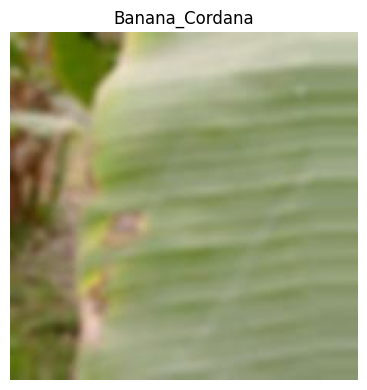


🌿 Class: Banana_Healthy


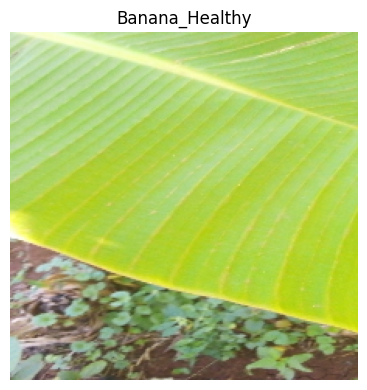


🌿 Class: Banana_Panama Disease


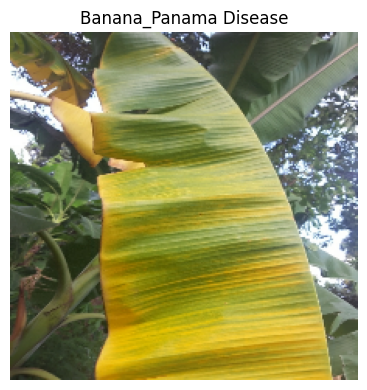


🌿 Class: Banana_Pestalotiopsis


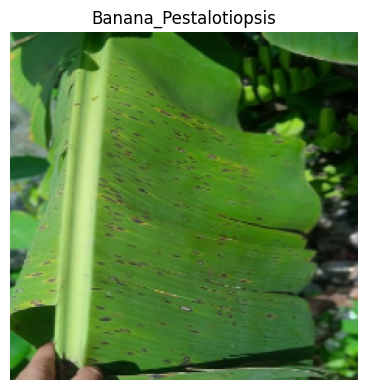


🌿 Class: Banana_Yellow and Black Sigatoka


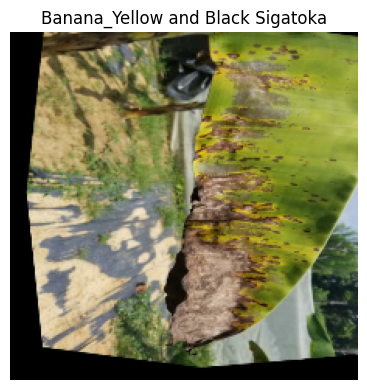


🌿 Class: Coconut_Bud Root Dropping


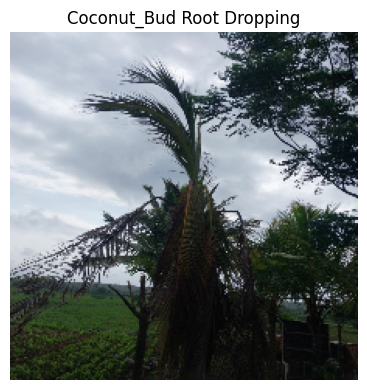


🌿 Class: Coconut_Bud Rot


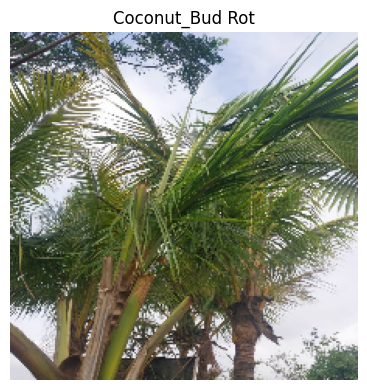


🌿 Class: Coconut_Gray Leaf Spot


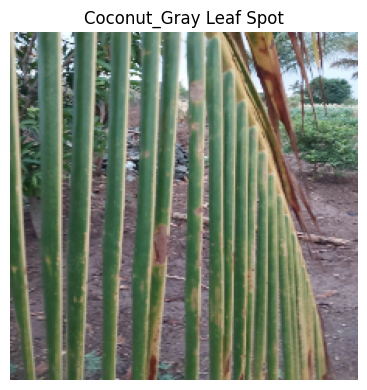


🌿 Class: Coconut_Healthy


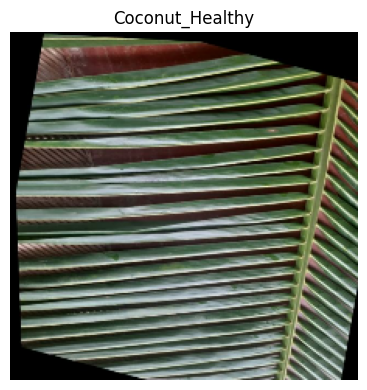


🌿 Class: Coconut_Leaf Rot


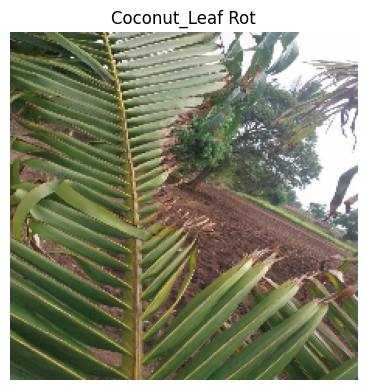


🌿 Class: Coconut_WCLWD_DryingofLeaflets


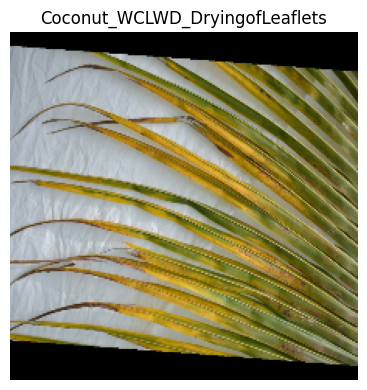


🌿 Class: Coconut_WCLWD_Flaccidity


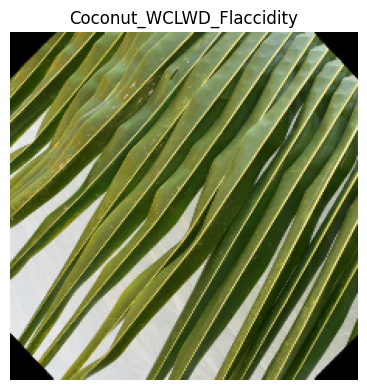


🌿 Class: Coconut_WCLWD_Yellowing


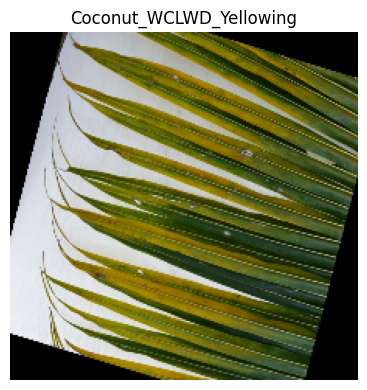


🌿 Class: Sugarcane_Healthy


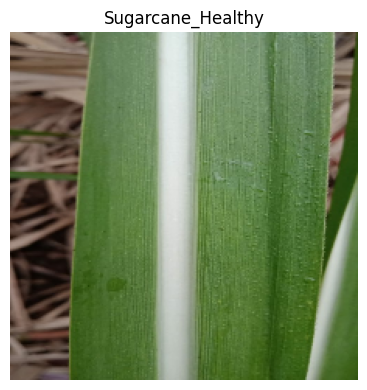


🌿 Class: Sugarcane_Mosaic


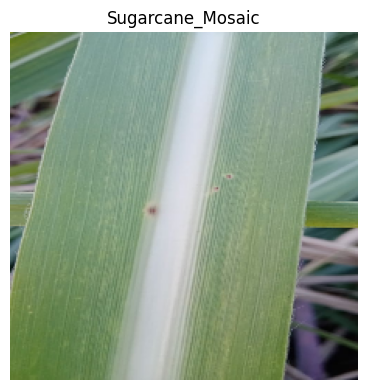


🌿 Class: Sugarcane_RedRot


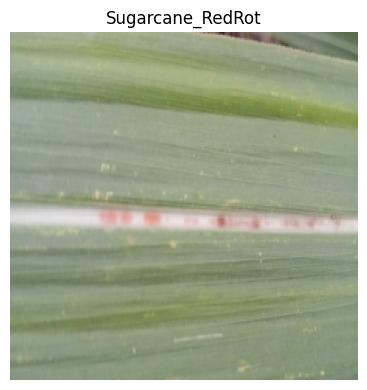


🌿 Class: Sugarcane_Rust


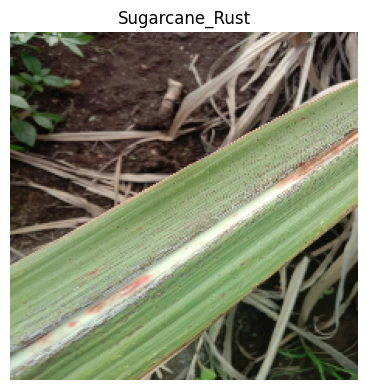


🌿 Class: Sugarcane_Yellow


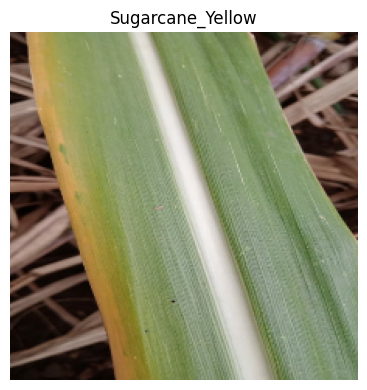

In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt

TRAIN_AUGMENTED_DIR = AUGMENT_DIR
IMG_SIZE = (224, 224)

def show_samples_per_class(directory):
    for disease_class in sorted(os.listdir(directory)):
        class_path = os.path.join(directory, disease_class)
        if not os.path.isdir(class_path):
            continue

        print(f"\n🌿 Class: {disease_class}")
        img_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(IMG_EXTENSIONS)
        ]
        if not img_files:
            print("No images found. Skipping.")
            continue

        plt.figure(figsize=(4, 4))
        img_file = random.choice(img_files)
        img_path = os.path.join(class_path, img_file)

        img = tf.io.read_file(img_path)
        img = tf.image.decode_image(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.uint8)

        plt.imshow(img.numpy())
        plt.title(disease_class)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

show_samples_per_class(TRAIN_DIR)